# MODAL PHY473
## Moteur géométrique et premier modèle

In [34]:
#Importations préalables
from __future__ import annotations
from dataclasses import dataclass
from typing import Tuple, Optional
import numpy as np
import pyvista as pv
#from .geometry import Géométrie, Vecteur, Rayon, Scintillateur
#from .ui import launch_ui
import matplotlib.pyplot as plt
import scipy.constants
from scipy.constants import physical_constants
import math
import nest_asyncio
nest_asyncio.apply()
pv.set_jupyter_backend('trame')

### 1. Moteur géométrique
#### 1.1. Introduction et principe

Pour effectuer une simulation physique des échanges d'énergie et de l'émission de photons dans un scintillateur plastique, nous devons d'abord commencer par coder sur Python notre **moteur géométrique**, qui devra être capable de réaliser les missions suivantes : 
- Génerer un **volume** défini par 8 points qui sera notre **scintillateur**.
- Génerer un objet géométrique défini par la donnée d'un point d'origine et d'un vecteur directeur, qui sera notre **rayon incident du muon**.
- Fournir les méthodes de calcul pour déterminer **si oui ou non le faisceau incident intersecte le scintillateur**, et, si oui, **la distance de parcours du muon dans le scintillateur ainsi que les points d'entrée et de sortie**. 

Les élements en 3D seront gérés par la bibliothèque python dédiée **PyVista**

### 1.2. Code

#### 1.2.1 Classe Vecteur

On se place dans un repère de coordonnées cartésiennes ($\vec{e}_x$, $\vec{e}_y$, $\vec{e}_z$). Chaque instance de la **classe Vecteur** est la données de coordonnées **($v_x$, $v_y$, $v_z$)** et d'un point d'origine. Les points seront représentés par des **Tuple**. On fournit également les méthodes élementaires : 
- **Produit scalaire**
- **Norme**
- **Normalisation**
- Une méthode **asTuple()** qui retourne le Tuple des coordonnées cartésiennes du vecteur. 

Ainsi que deux méthodes de tracé, qui permettent de créer un tracé avec un vecteur ou d'ajouter un vecteur sur un tracé existant : 
- La méthode **plot3Dvect()**, qui renvoie un tel tracé
- La méthode **showPlot3DVect()**, qui permet d'afficher le tracé renvoyé par la méthode précédente

In [28]:
@dataclass(frozen=True)
class Vecteur:
    vx: float
    vy: float
    vz: float
    origin: Tuple[float, float, float]

    def produit_scalaire(self, a: "Vecteur") -> float:
        return self.vx * a.vx + self.vy * a.vy + self.vz * a.vz

    def norme(self) -> float:
        return float(np.sqrt(self.vx * self.vx + self.vy * self.vy + self.vz * self.vz))

    def normalize(self) -> "Vecteur":
        n = self.norme()
        if n == 0:
            raise ValueError("Impossible de normaliser un vecteur nul.")
        return Vecteur(self.vx / n, self.vy / n, self.vz / n, self.origin)

    def asTuple(self) -> Tuple[float, float, float]:
        return (self.vx, self.vy, self.vz)
    
    def plot3DVect(self, plotter: Optional[pv.Plotter] = None, *, scale: Optional[float] = None) -> pv.Plotter:
        if plotter is None:
            plotter = pv.Plotter()

        o = np.array(self.origin, dtype=float)
        v = np.array([self.vx, self.vy, self.vz], dtype=float)
        n = np.linalg.norm(v)
        if n == 0:
            raise ValueError("Vecteur nul : rien à tracer.")

        # longueur de la flèche
        length = float(scale) if scale is not None else float(n)

        # PyVista : Arrow(start, direction, scale)
        # direction : vecteur directeur (pas forcément unitaire), scale ~ longueur
        direction = v / n  # unitaire
        arrow = pv.Arrow(start=o, direction=direction, scale=length)

        plotter.add_mesh(arrow, color="black")
        return plotter

    def showPlot3DVect(self, plotter: Optional[pv.Plotter] = None, *, scale: Optional[float] = None) -> None:
        plotter = self.plot3DVect(plotter=plotter, scale=scale)
        plotter.show()

#### 1.2.2 Classe Rayon

Maintenant que nous avons codé la classe élementaire Vecteur, nous pouvons coder les objets géométriques qui interviendront dans notre simulation physique, à commencer par un rayon géométrique, **donnée d'un vecteur** et muni des méthodes suivantes : 
- **vecteur_directeur()**, retourne le vecteur directeur normalisé du rayon
- **origine()**, retourne l'origine du vecteur du rayon

Ainsi que deux méthodes de tracé selon le **même principe que la classe Vecteur**.  

In [29]:
@dataclass(frozen=True)
class Rayon:
    v: Vecteur

    def vecteur_directeur(self) -> Vecteur:
        return self.v.normalize()

    def origine(self) -> Tuple[float, float, float]:
        return self.v.origin

    def plot3DRay(self, plotter: Optional[pv.Plotter]) -> pv.Plotter:
        if plotter is None:
            raise ValueError("plotter is None : tracez le scintillateur (ou la scène) avant le rayon.")

        vdir = self.vecteur_directeur()
        P0 = np.array(self.origine(), dtype=float)
        d = np.array([vdir.vx, vdir.vy, vdir.vz], dtype=float)

        b = plotter.bounds 
        if any(np.isinf(b)) or any(np.isnan(b)):
            L = 10.0
        else:
            dx = b[1] - b[0]
            dy = b[3] - b[2]
            dz = b[5] - b[4]
            diag = float(np.sqrt(dx * dx + dy * dy + dz * dz))
            L = 1 * diag if diag > 0 else 5

        P1 = P0 + L * d

        # PyVista line
        line = pv.Line(P0, P1)

        plotter.add_mesh(line, color="red", line_width=3)
        #fleche au départ pour indiquer le sens
        arrow = pv.Arrow(start=P0, direction=d, scale=min(L * 0.15, 5.0))
        plotter.add_mesh(arrow, color="red")
        return plotter

    def showPlot3DRay(self, plotter: Optional[pv.Plotter]) -> None:
        plotter = self.plot3DRay(plotter)
        plotter.show()

#### 1.2.2 Classe Scintillateur

Le scintillateur est l'objet géométrique le plus complexe que nous manipulons. Il est la donnée d'un ensemble de **8 points** et fournit de nombreuses méthodes essentielles à la poursuite de la simulation :
- **points()**, retourne l'ensemble des points du scintillateur
- **intersect_points_oriented(rayon : Rayon)**, fonction la plus essentielle de la simulation. Prend en argument un scintillateur et un rayon, et détermine :
    - Si il y a intersection
    - Les coordonnées cartésiennes des points d'entrée et de sortie du rayon s'il y a intersection.
    - Pour cela, on se place dans une base adaptée à notre hexaèdre et on construit une **matrice de changement de base** qui permet d'exprimer les coordonnées du rayon dans cette base. 
- **_as_hexahedron_grid()** : constuit un hexaèdre VTK (interprétable par pyVista) à partir de la classe python que nous avons construite. Pour cela, 
- **plot_intersections_red(rayon : Rayon, plotter : pv.plotter)** qui permet de tracer les deux points d'entrée et de sortie sdu rayon, si toutefois il y en a. 

Ainsi que deux méthodes de tracé selon le **même principe que les classes Vecteur et Rayon**.  

In [30]:
@dataclass(frozen=True)
class Scintillateur:
    A1: Tuple[float, float, float]
    A2: Tuple[float, float, float]
    A3: Tuple[float, float, float]
    A4: Tuple[float, float, float]
    B1: Tuple[float, float, float]
    B2: Tuple[float, float, float]
    B3: Tuple[float, float, float]
    B4: Tuple[float, float, float]

    def points(self):
        return [self.A1, self.A2, self.A3, self.A4,
                self.B1, self.B2, self.B3, self.B4]

    def intersect_points_oriented(self, ray: "Rayon", eps: float = 1e-12):
    # --- Base du parallélépipède (monde -> local)
        A1 = np.asarray(self.A1, dtype=float)
        u  = np.asarray(self.A2, dtype=float) - A1
        v  = np.asarray(self.A4, dtype=float) - A1
        w  = np.asarray(self.B1, dtype=float) - A1

        M = np.column_stack([u, v, w])  # 3x3

        det = float(np.linalg.det(M))
        if abs(det) < eps:
            raise ValueError("Base non inversible (u,v,w coplanaires ou nuls).")

        Minv = np.linalg.inv(M)

        O = np.asarray(ray.origine(), dtype=float)
        vd = ray.vecteur_directeur()
        D = np.asarray([vd.vx, vd.vy, vd.vz], dtype=float)

        p0 = Minv @ (O - A1)
        d  = Minv @ D

        # --- Intersection rayon avec AABB local [0,1]^3
        tmin = -np.inf
        tmax =  np.inf

        for i in range(3):
            if abs(d[i]) < eps:
                # Rayon parallèle aux plans de cette dimension
                if p0[i] < 0.0 or p0[i] > 1.0:
                    return False, None, None
            else:
                t1 = (0.0 - p0[i]) / d[i]
                t2 = (1.0 - p0[i]) / d[i]
                t_enter = min(t1, t2)
                t_exit  = max(t1, t2)

                tmin = max(tmin, t_enter)
                tmax = min(tmax, t_exit)

                if tmin > tmax:
                    return False, None, None

        # --- Demi-droite: on impose t >= 0
        if tmax < 0:
            return False, None, None

        t_enter_world = max(tmin, 0.0)
        t_exit_world  = tmax

        P_enter = O + t_enter_world * D
        P_exit  = O + t_exit_world  * D

        return True, tuple(P_enter), tuple(P_exit)

    def _as_hexahedron_grid(self) -> pv.UnstructuredGrid:
        """
        Construit un hexaèdre VTK à partir des 8 points dans l'ordre:
        [A1,A2,A3,A4,B1,B2,B3,B4]
        """
        pts = np.asarray(self.points(), dtype=float)

        # Cell connectivity for a single HEXAHEDRON:
        # [8, 0,1,2,3,4,5,6,7]
        cells = np.array([8, 0, 1, 2, 3, 4, 5, 6, 7], dtype=np.int64)
        celltypes = np.array([pv.CellType.HEXAHEDRON], dtype=np.uint8)

        grid = pv.UnstructuredGrid(cells, celltypes, pts)
        return grid

    def plot_intersections_red(self, ray: "Rayon", plotter: Optional[pv.Plotter], *,
                           point_size: float = 4.0,
                           show_segment_inside: bool = True,
                           eps: float = 1e-12) -> pv.Plotter:

        if plotter is None:
            raise ValueError("plotter is None : créez d'abord la scène (ex: via plot3DScint).")

        hit, Pin, Pout = self.intersect_points_oriented(ray, eps=eps)
        if not hit:
            return plotter  # rien à afficher

        pts = np.array([Pin, Pout], dtype=float)

        # Points verts (sphères)
        pts_poly = pv.PolyData(pts)
        plotter.add_mesh(
            pts_poly,
            color="green",
            point_size=point_size,
            render_points_as_spheres=True
        )

        # (option) Segment intérieur
        if show_segment_inside:
            seg = pv.Line(pts[0], pts[1])
            plotter.add_mesh(seg, color="green", line_width=4)

        return plotter

    def plot3DScint(self, plotter: Optional[pv.Plotter], *,
                    show_points: bool = True,
                    show_edges: bool = True,
                    color: str = "lightblue",
                    opacity: float = 0.35) -> pv.Plotter:
        if plotter is None:
            plotter = pv.Plotter()

        grid = self._as_hexahedron_grid()

        # Surface (faces)
        surf = grid.extract_surface()

        plotter.add_mesh(
            surf,
            color=color,
            opacity=opacity,
            show_edges=show_edges,
            edge_color="black"
        )

        # Points (sommets)
        if show_points:
            pts_poly = pv.PolyData(np.asarray(self.points(), dtype=float))
            plotter.add_mesh(pts_poly, color="black", point_size=10, render_points_as_spheres=True)

        return plotter

    def showPlot3DScint(self, plotter: Optional[pv.Plotter] = None, **kwargs) -> None:
        plotter = self.plot3DScint(plotter=plotter, **kwargs)
        plotter.show()


#### 1.2.4. Classe Géométrie

La classe Géométrie regroupe les élements précédents en une seule et même classe, ce qui permet de manipuler un objet global donné par un **scintillateur** et un **rayon**. Elle fournit également les méthodes :
- **données_origine_rayon()**, **donnée_rayon_vecteur_directeur()**, **données_scint()** qui permettent d'accéder aux données des composantes de l'objet **géométrie**.
- **intersection_bool()**, qui retourne un booléen qui vaut True s'il y a intersection. 
- **intersection_points()**, qui retourne les coordonnées des points d'entrée et sortie du rayon s'il y a intersection. 
- **intersection_longueur()**, qui retourne la longueur de parcours du muon dans le scintillateur. 

Et enfin, deux méthodes de tracé sur le même principe que les trois classes plus haut. 

In [31]:
@dataclass()
class Géométrie :
    scintillateur : Scintillateur
    rayon : Rayon
    def données_origine_rayon(self) :
        return self.rayon.origine()

    def donnée_rayon_vecteur_directeur(self) :
        return self.rayon.vecteur_directeur()

    def données_scint(self) :
        return self.scintillateur.points()

    def intersection_bool(self) :
        bool, point_entrée, point_sortie = self.scintillateur.intersect_points_oriented(ray=self.rayon)
        return bool

    def intersection_points(self) :
        bool, point_entrée, point_sortie = self.scintillateur.intersect_points_oriented(ray=self.rayon)
        return point_entrée, point_sortie

    def intersection_longueur(self) :
        if self.intersection_bool() :
            point_entrée, point_sortie = self.intersection_points()
            return Vecteur(point_sortie[0]-point_entrée[0],
                        point_sortie[1]-point_entrée[1],
                        point_sortie[2]-point_entrée[2],
                        origin=(0,0,0)).norme()
        else :
            return None

    def plot(self) :
        plotter = self.scintillateur.plot3DScint(plotter=None, color="lightblue", opacity=0.35, show_edges=True, show_points=True)
        plotter = self.scintillateur.plot_intersections_red(plotter=plotter, ray=self.rayon)
        plotter.add_axes()
        
        point_entrée, point_sortie = self.intersection_points()
        plotter.add_text(
        "Titien Adouani\n"
        "Muon in scintillator simulator\n"
        f"Intersection : {self.intersection_bool()}\n"
        f"Longueur de parcours : {self.intersection_longueur()}\n"
        f"Point d'entrée : {point_entrée}\n"
        f"Point de sortie : {point_sortie}",
        position="upper_right",
        font_size=8,
        color="black",
        shadow=True,
        viewport=True
        )
        return plotter

    def showplot(self) :
        plotter = self.plot()
        self.rayon.showPlot3DRay(plotter=plotter)

C:\Users\Adouani\AppData\Local\Temp\ipykernel_7600\1967326032.py:127: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surf = grid.extract_surface()
C:\Users\Adouani\AppData\Local\Temp\ipykernel_7600\2793906434.py:42: UserWarning: Failed to use notebook backend: 

Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
  plotter.show()


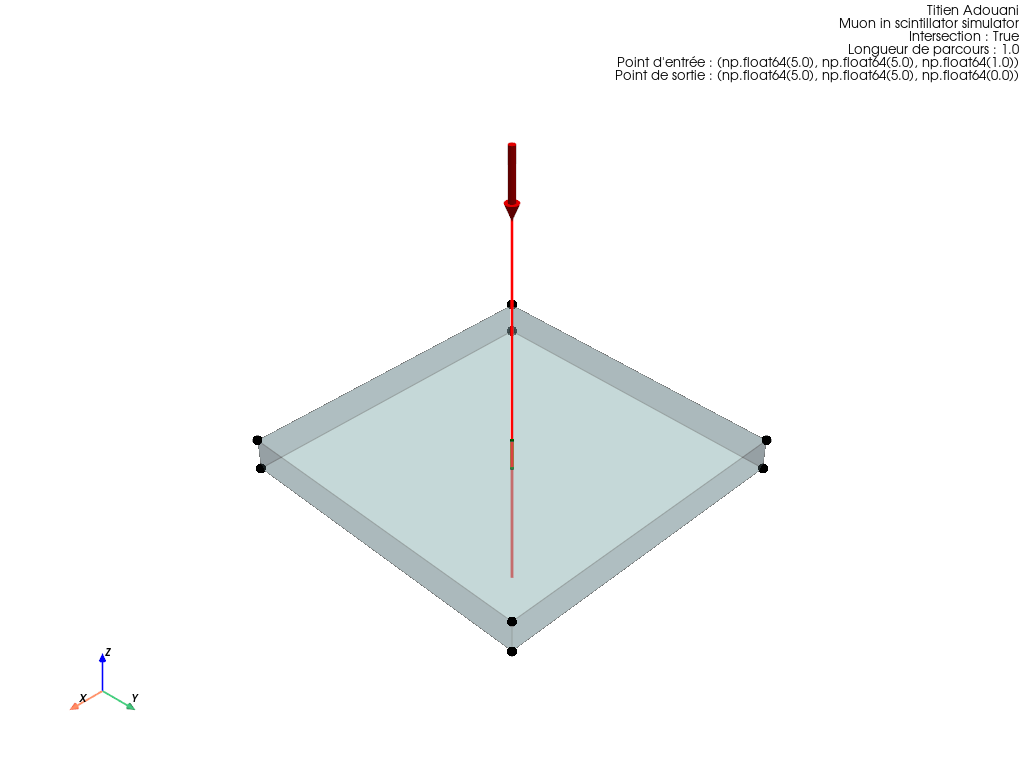

In [ ]:
# EXEMPLE 
# ATTENTION : dans la version actuelle, 
# fonctionne uniquement avec des scintillateurs
# parallépipédiques orientés dans le sens de la longueur 
# et de la largeur selon les axes ex et ey.

Scint = Scintillateur(
    (0,0,0),  # A1
    (10,0,0),  # A2
    (10,10,0),  # A3
    (0,10,0),  # A4
    (0,0,1),  # B1
    (10,0,1),  # B2
    (10,10,1),  # B3
    (0,10,1)   # B4
)

Ray = Rayon(Vecteur(0, 0, -1, (5, 5, 10)))

géométrie = Géométrie(scintillateur=Scint, rayon=Ray)
géométrie.showplot()

### 2. Moteur physique et simulation
#### 2. 1. Fondamentaux et principe de la modélisation
##### 2. 1. 1. Physique de la simulation

Le muon $\mu_-$ est une particule de charge $-e$, relativiste, munie d'une certaine vitesse $\beta c$, d'une masse $m_{\mu} = 207m_e$, avec $m_e$ masse de l'électron. 

Dans le cadre de ce premier modèle, nous ne modélisons pas les interactions évênement par évênement, mais supposont les échanges d'énergie entre la particule et le scintillateur intégralement décrits par la **formule de Bethe et Bloch** (qui donne en fait une valeur moyenne). 

Son expression est la suivante :

$$
-\frac{dE}{dx} = K z^2 \frac{Z}{A}\frac{1}{\beta^2}(\frac{1}{2}ln(\frac{2 m_e c^2 \beta^2 \gamma^2(\beta)T_{max}}{I^2}) - \beta^2)
$$
avec 
$$
K = 4 \pi N_A r_e^2 m_e c^2 \rho
$$
et T_max énergie cinétique maximale transmettable à un électron libre du milieu, donnée par :
$$
T_{max} = \frac{2 m_e c^2 \beta^2 \gamma^2(\beta)}{1 + 2 \gamma(\beta) \frac{m_e}{m_\mu} + (\frac{m_e}{m_\mu})^2}
$$
Où : 
- $Z$ numéro atomique des atomes du milieu traversé
- $A$ masse molaire du milieu 
- $z=-1$ charge du muon
- $\rho$ masse volumique du milieu

en unités SI. 


Nous commençons par tracer la courbe de Bethe et Bloch en fonction de $\gamma \beta$. Pour ça, nous définissons dans python les **constantes physiques nécessaires**, en assimilant en première approximation tous les atomes de notre milieu à des atomes de carbone.  

In [64]:
#region constantes
pi = math.pi
c = scipy.constants.c
eV = scipy.constants.electron_volt
me = scipy.constants.electron_mass
e = scipy.constants.elementary_charge
E0 = scipy.constants.epsilon_0
h = scipy.constants.Planck
r_e = physical_constants['classical electron radius'][0]
hbarre = h/(2*pi)
z=-1

m_mu = 207*me
I = 68.7*eV 
rho = 1060        
A   = 12.0e3          
Z   = 6             
Na  = scipy.constants.Avogadro
I   = 68.7 * eV     
n   = (Z * rho * Na) / A

Puis la **formule de Bethe et Bloch** ainsi que les formules auxiliaires pour les grandes **$T_{max}$**, **$\gamma$**, **$\beta$**, et **$p=\gamma m_{\mu} v$**:

In [68]:
def gamma(beta) :
    if np.any(beta>1) :
        raise ValueError("beta doit être compris entre -1 et 1")
    return 1/np.sqrt(1-(beta)**2)
    
def T_max(beta):
    if np.any(beta>1) :
        raise ValueError("Beta doit être compris entre -1 et 1")
    gamma_ = gamma(beta)
    if np.any(gamma_<1) :
        raise ValueError("Gamma doit être supérieur ou égal à 1")
    numerateur = 2*me*(c**2)*(beta**2)*(gamma_**2)
    denominateur = 1+2*gamma_*(me/m_mu) + (me/m_mu)**2
    return numerateur/denominateur

def impulsion(beta) :
    gamma_ = gamma(beta)
    return beta*gamma_*c*m_mu

def energie_relativiste(beta) :
    return np.sqrt((m_mu**2)*(c**4) + (impulsion(beta)**2)*(c**2))

def BetheBloch(beta) :
    if np.any(beta>1) :
        raise ValueError("Beta doit être compris entre -1 et 1")
    gamma_ = gamma(beta)
    if np.any(gamma_<1) :
        raise ValueError("Gamma doit être supérieur ou égal à 1")
    K = 4*pi*Na*r_e**2*me*c**2
    arglog = (2*me*(c**2)*(beta)**2)*T_max(beta)/((I**2)*(1-(beta**2)))
    return (K*(z**2)*(Z*rho/A)*(1/((beta)**2)))*(0.5*np.log(arglog) - (beta**2))


Nous traçons ici la courbe de Bethe et Bloch avec les valeurs retenues pour notre scintillateur :

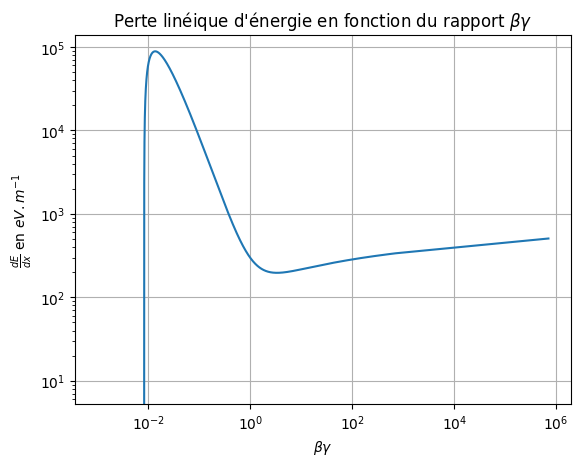

In [69]:
beta = np.linspace(1e-3, 1-1e-12, int(1e6))
gamma_ = gamma(beta)
gamma_beta = beta*gamma_
bethe_bloch = BetheBloch(beta)/eV
plt.plot(gamma_beta, bethe_bloch)
plt.xscale('log')
plt.xlabel(r"$\beta \gamma$")
plt.yscale('log')
plt.ylabel(r"$\frac{dE}{dx}$ en $eV.m^{-1}$")
plt.title(r"Perte linéique d'énergie en fonction du rapport $\beta \gamma$")
plt.grid()
plt.show()

Nous définissons trois fonctions auxilliaires qui seront utilisées dans la suite du programme :

In [67]:
def E_photon() :
    #tirage uniforme dans le spectre d'émission du scintillateur
    longueur_donde = np.random.uniform(low=350, high = 550)
    longueur_donde = 1e-9*longueur_donde
    return h*(c/longueur_donde)

def exponentiall_decay(dt) :
    Tau = 2*10e-9
    return np.exp(-dt/Tau)

def _index_3d(i, j, k, nx, ny, nz):
    # index point dans la grille de points (nx+1, ny+1, nz+1)
    return i + (nx + 1) * (j + (ny + 1) * k)


##### 2. 1. 2. Principe de la simulation et discrétisation

Nous retenons la stratégie suivante pour notre premier modèle :
- Considérer un objet de la classe Géométrie étudiée plus haut, muni d'un rayon et d'un scintillateur
- Décomposer notre scintillateur étudié en petits scintillateurs élementaires
    - Pour cela, on se munira d'une classe Stepping, qui encapsulera la classe Géométrie. 
    - On se servira des fonctions déjà implémentées dans pyVista de calculs de discrétisation des volumes.
- Ensuite, considérer dans l'ordre nos scintillateurs élementaires  